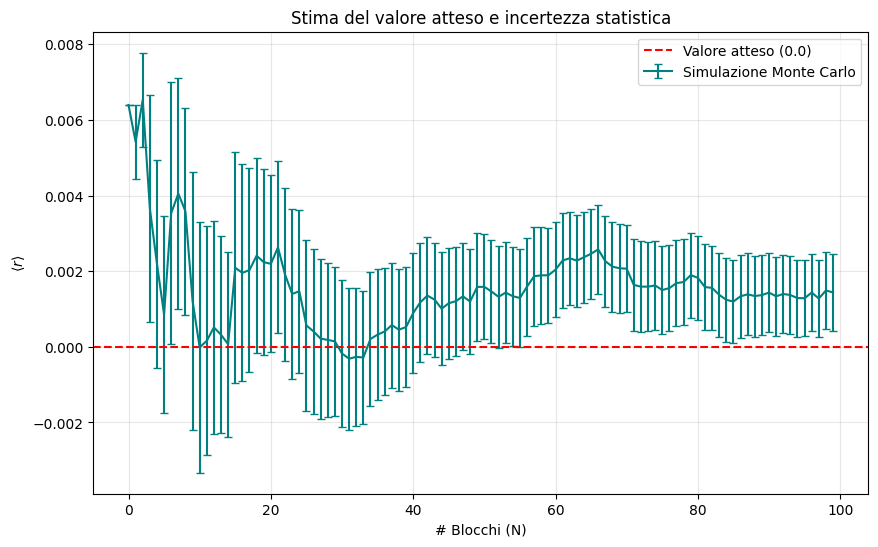

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Carichiamo i dati
# Assicurati che il nome del file sia lo stesso che hai usato nel C++
try:
    data = np.loadtxt("output_ave.dat")
    x = data[:,0]           # Numero del blocco (0, 1, 2...)
    sum_prog = data[:,1]    # Media progressiva
    err_prog = data[:,2]    # Incertezza (deviazione standard della media)

    # 2. Creiamo il grafico
    plt.figure(figsize=(10,6))
    plt.errorbar(x, sum_prog, yerr=err_prog, color='teal', label='Simulazione Monte Carlo', capsize=3)
    
    # Linea del valore atteso teorico (l'integrale di r dr tra 0 e 1 è 0.5)
    plt.axhline(y=0.0, color='red', linestyle='--', label='Valore atteso (0.0)')
    
    plt.xlabel('# Blocchi (N)')
    plt.ylabel(r'$\langle r \rangle$')
    plt.title('Stima del valore atteso e incertezza statistica')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

except FileNotFoundError:
    print("Errore: Il file 'output_ave.dat' non è stato trovato. Controlla il percorso!")

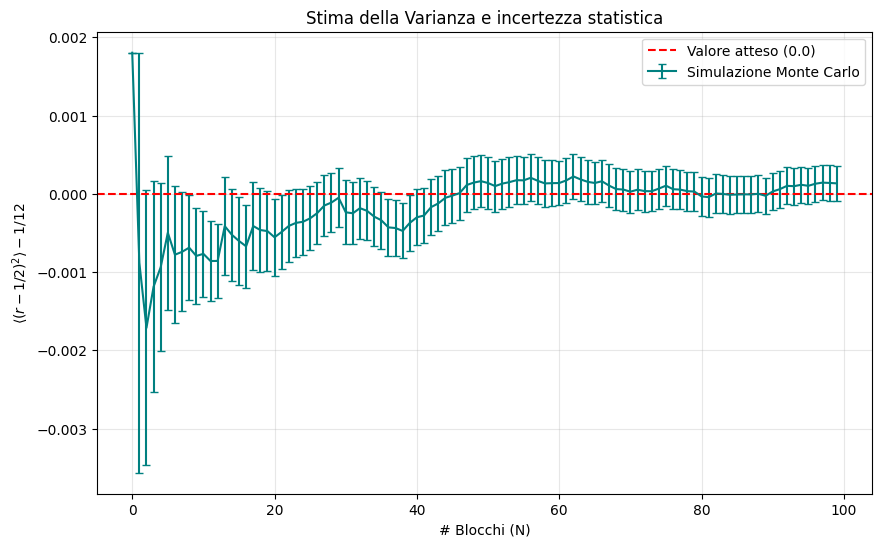

In [5]:
try:
    data = np.loadtxt("output_sigma.dat")
    x = data[:,0]           
    sum_prog = data[:,1]    
    err_prog = data[:,2]    

    plt.figure(figsize=(10,6))
    plt.errorbar(x, sum_prog, yerr=err_prog, color='teal', label='Simulazione Monte Carlo', capsize=3)
    
    # Poiché hai sottratto 1/12 in C++, il valore atteso è ora 0.0
    plt.axhline(y=0.0, color='red', linestyle='--', label='Valore atteso (0.0)')
    
    plt.xlabel('# Blocchi (N)')
    plt.ylabel(r'$\langle (r-1/2)^2 \rangle - 1/12$') # Etichetta più precisa
    plt.title('Stima della Varianza e incertezza statistica')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

except FileNotFoundError:
    print("Errore: Il file 'output_sigma.dat' non è stato trovato!")

In [8]:
%pip install scipy

   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   --- ------------------------------------ 3.1/37.3 MB 28.9 MB/s eta 0:00:02
   ----------------- ---------------------- 16.5/37.3 MB 40.6 MB/s eta 0:00:01
   -------------------------- ------------- 25.2/37.3 MB 44.4 MB/s eta 0:00:01
   ------------------------------ --------- 28.6/37.3 MB 34.6 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 35.8 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


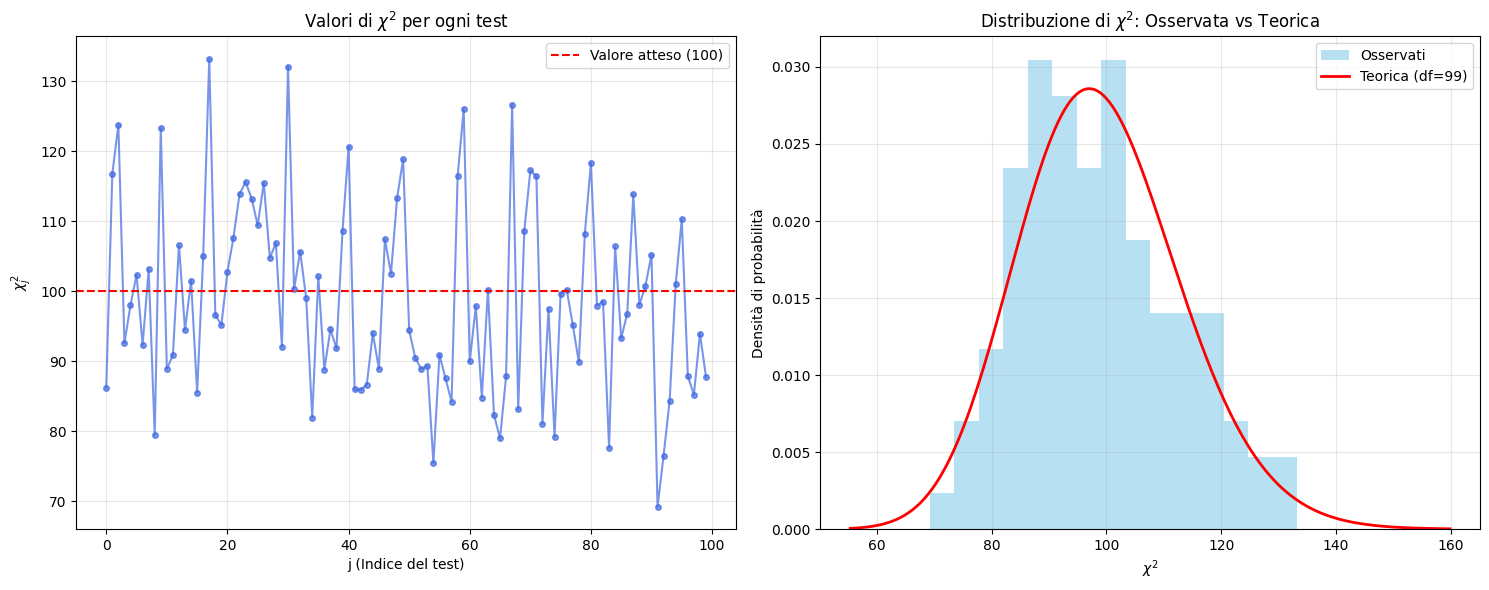

Media dei valori di Chi-quadro ottenuti: 98.79


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2

# 1. Caricamento dati
# Assicurati che il nome del file sia lo stesso usato in C++
try:
    data = np.loadtxt("output_chi2.dat")
except FileNotFoundError:
    print("Errore: Il file 'output_chi2.dat' non è stato trovato!")
    # Inserisco dati fittizi solo per non far crashare lo script se non hai ancora il file
    data = np.array([[i, 100 + np.random.normal(0, 10)] for i in range(100)])

# Divido le colonne
x = data[:, 0]   # Indice j del test (0, 1, ..., 99)
y = data[:, 1]   # Valori di chi^2 calcolati

# 2. Configurazione figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- PRIMO GRAFICO: Scatter plot dei test ---
ax1.plot(x, y, marker='o', linestyle='-', color='royalblue', markersize=4, alpha=0.7)
ax1.axhline(y=100, color='red', linestyle='--', label='Valore atteso (100)')
ax1.set_xlabel("j (Indice del test)")
ax1.set_ylabel(r"$\chi_j^2$")
ax1.set_title(r"Valori di $\chi^2$ per ogni test")
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- SECONDO GRAFICO: Istogramma vs Distribuzione Teorica ---
# Gradi di libertà: M - 1 (dove M=100 intervalli)
df = 99 

# Istogramma dei dati osservati
ax2.hist(y, bins=15, density=True, alpha=0.6, color='skyblue', label='Osservati')

# Distribuzione teorica del Chi-quadro
x_teor = np.linspace(min(y)*0.8, max(y)*1.2, 200)
y_teor = chi2.pdf(x_teor, df=df)
ax2.plot(x_teor, y_teor, 'r-', lw=2, label=f'Teorica (df={df})')

ax2.set_xlabel(r"$\chi^2$")
ax2.set_ylabel("Densità di probabilità")
ax2.set_title(r"Distribuzione di $\chi^2$: Osservata vs Teorica")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stampa di controllo
print(f"Media dei valori di Chi-quadro ottenuti: {np.mean(y):.2f}")

<>:12: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:45: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:45: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:55: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:55: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:12: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences wil

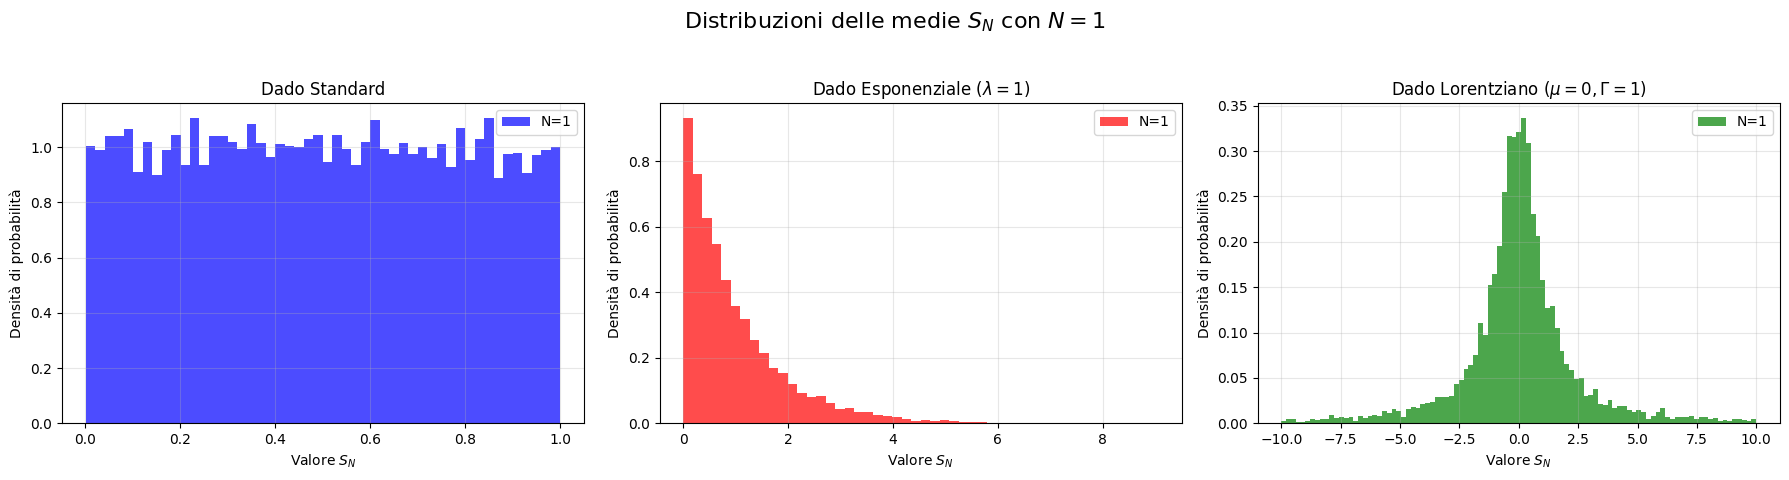

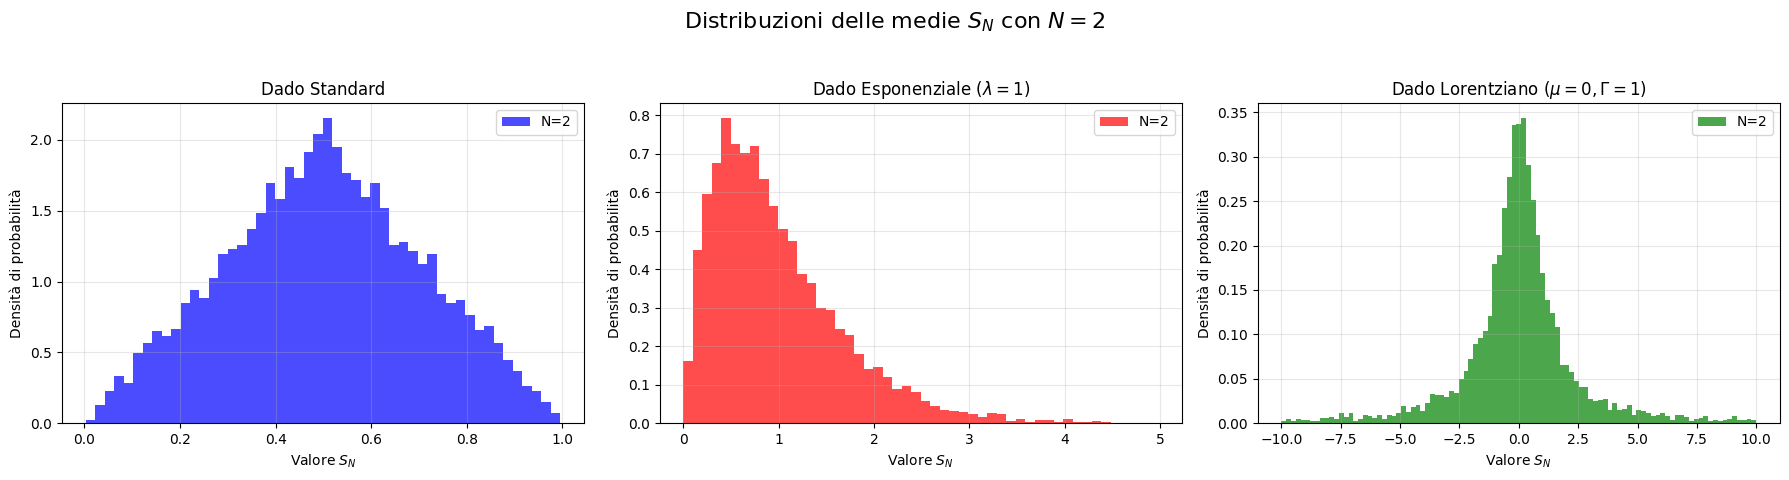

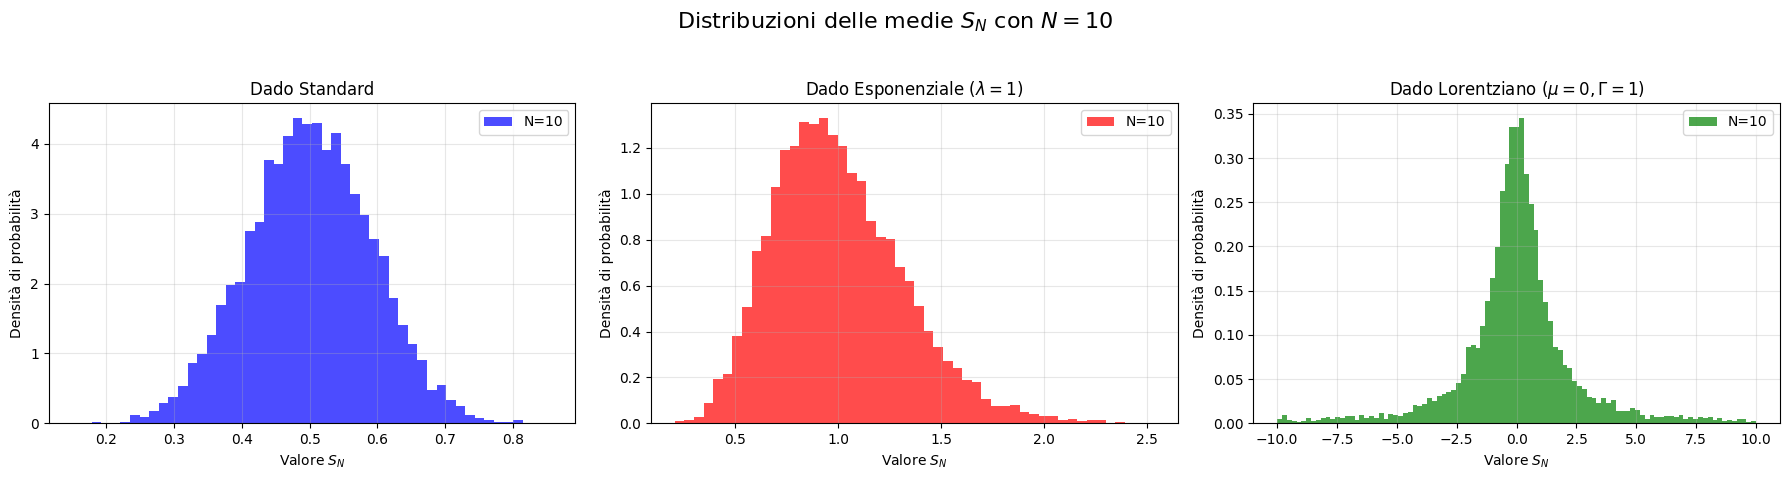

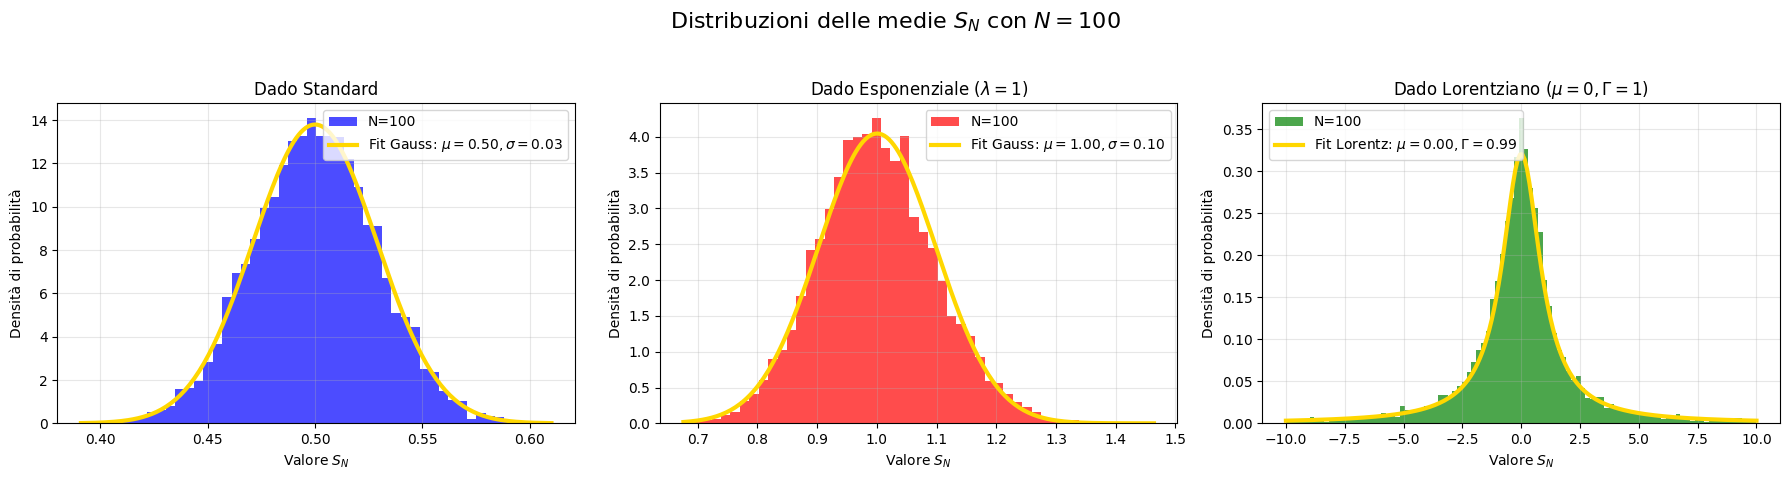

------------------------------
RISULTATI FIT PER N=100 (10^4 realizzazioni):
Standard [μ, σ]:      0.5000 ± 0.0003, 0.0289
Esponenziale [μ, σ]:  1.0005 ± 0.0010, 0.0986
Lorentziano [μ, Γ]:   0.0020 ± 0.0099, 0.9917
------------------------------


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, cauchy

# Carichiamo i tre file generati dal tuo C++
# Ogni file ha 10000 righe e 4 colonne (N=1, N=2, N=10, N=100)
data_uni = np.loadtxt("out_uni.dat")
data_exp = np.loadtxt("out_exp.dat")
data_lor = np.loadtxt("out_lor.dat")

datasets = [data_uni, data_exp, data_lor]
titles = ["Dado Standard", "Dado Esponenziale ($\lambda=1$)", "Dado Lorentziano ($\mu=0, \Gamma=1$)"]
colors = ['b', 'r', 'g']
N_values = [1, 2, 10, 100]

# Iteriamo sui 4 valori di N (le 4 colonne dei tuoi file)
for i, N in enumerate(N_values):
    # Creazione di una figura con 1 riga e 3 colonne per ogni N
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Distribuzioni delle medie $S_N$ con $N={N}$", fontsize=16)

    for j in range(3):
        # Estraiamo la colonna i-esima (corrispondente a N) dal dataset j-esimo (tipo di dado)
        current_data = datasets[j][:, i]
        
        # Definiamo i bin in base al tipo di dado
        if j == 2: # Lorentziano: limitiamo il range per vedere il picco (ha code lunghe!)
            bins = np.linspace(-10, 10, 100)
        else:
            bins = 50

        axes[j].hist(current_data, bins=bins, density=True, alpha=0.7, color=colors[j], label=f'N={N}')
        axes[j].set_title(titles[j])
        axes[j].set_xlabel("Valore $S_N$")
        axes[j].set_ylabel("Densità di probabilità")
        axes[j].grid(True, alpha=0.3)

        # Se siamo all'ultimo valore di N (N=100), facciamo i Fit
        if N == 100:
            x = np.linspace(min(current_data), max(current_data), 200)
            
            if j < 2: # Fit Gaussiano per Standard ed Esponenziale
                mu, sigma = norm.fit(current_data)
                y = norm.pdf(x, mu, sigma)
                axes[j].plot(x, y, color='gold', lw=3, label=f'Fit Gauss: $\mu={mu:.2f}, \sigma={sigma:.2f}$')
                
                # Salviamo i parametri per la stampa finale
                if j == 0: std_params = (mu, sigma)
                if j == 1: exp_params = (mu, sigma)
                
            else: # Fit di Cauchy per il Lorentziano
                x_lor = np.linspace(-10, 10, 200)
                mu_l, gamma_l = cauchy.fit(current_data)
                y_lor = cauchy.pdf(x_lor, loc=mu_l, scale=gamma_l)
                axes[j].plot(x_lor, y_lor, color='gold', lw=3, label=f'Fit Lorentz: $\mu={mu_l:.2f}, \Gamma={gamma_l:.2f}$')
                lor_params = (mu_l, gamma_l)
        
        axes[j].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- STAMPA DEI PARAMETRI FINALI (N=100) ---
print("-" * 30)
print(f"RISULTATI FIT PER N=100 (10^4 realizzazioni):")
print(f"Standard [μ, σ]:      {std_params[0]:.4f} ± {std_params[1]/np.sqrt(10000):.4f}, {std_params[1]:.4f}")
print(f"Esponenziale [μ, σ]:  {exp_params[0]:.4f} ± {exp_params[1]/np.sqrt(10000):.4f}, {exp_params[1]:.4f}")
print(f"Lorentziano [μ, Γ]:   {lor_params[0]:.4f} ± {lor_params[1]/np.sqrt(10000):.4f}, {lor_params[1]:.4f}")
print("-" * 30)

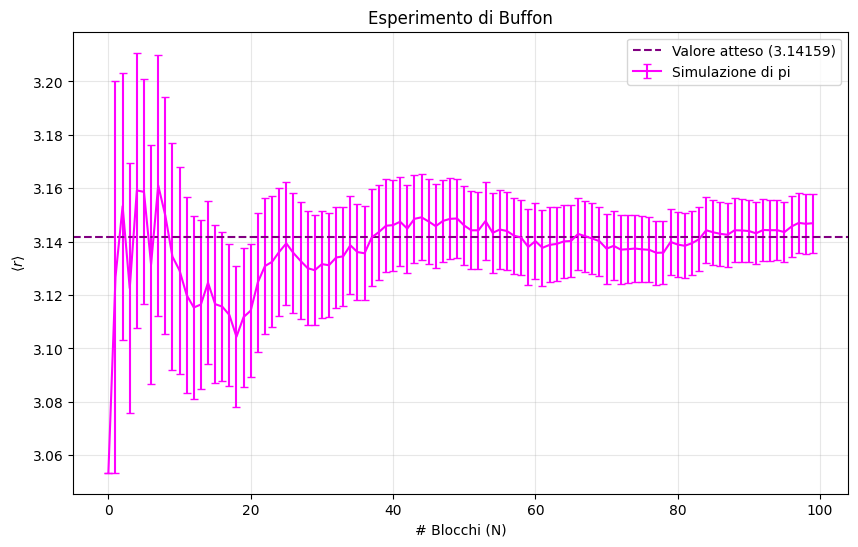

In [10]:
import matplotlib.pyplot as plt
import numpy as np

try:
    data = np.loadtxt("output_pi.dat")
    x = data[:,0]           # Numero del blocco (0, 1, 2...)
    sum_prog = data[:,1]    # Media progressiva
    err_prog = data[:,2]    # Incertezza (deviazione standard della media)

    # 2. Creiamo il grafico
    plt.figure(figsize=(10,6))
    plt.errorbar(x, sum_prog, yerr=err_prog, color='magenta', label='Simulazione di pi', capsize=3)
    
    # Linea del valore atteso teorico (l'integrale di r dr tra 0 e 1 è 0.5)
    plt.axhline(y=3.14159, color='purple', linestyle='--', label='Valore atteso (3.14159)')
    
    plt.xlabel('# Blocchi (N)')
    plt.ylabel(r'$\langle r \rangle$')
    plt.title('Esperimento di Buffon')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

except FileNotFoundError:
    print("Errore: Il file 'output_pi.dat' non è stato trovato. Controlla il percorso!")